<a href="https://colab.research.google.com/github/aimalhoonmein/AI2023369/blob/main/hotdog_classifier_aimalkhan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import random

print("Libraries loaded successfully!")
print("TensorFlow version:", tf.__version__)

Libraries loaded successfully!
TensorFlow version: 2.20.0


In [ ]:
!unzip /archive.zip

Archive:  /archive.zip
   creating: archive/
  inflating: __MACOSX/._archive      
   creating: archive/test/
  inflating: __MACOSX/archive/._test  
   creating: archive/seefood/
  inflating: __MACOSX/archive/._seefood  
   creating: archive/train/
  inflating: __MACOSX/archive/._train  
   creating: archive/test/not_hot_dog/
  inflating: __MACOSX/archive/test/._not_hot_dog  
   creating: archive/test/hot_dog/
  inflating: __MACOSX/archive/test/._hot_dog  
   creating: archive/seefood/test/
  inflating: __MACOSX/archive/seefood/._test  
   creating: archive/seefood/train/
  inflating: __MACOSX/archive/seefood/._train  
   creating: archive/train/not_hot_dog/
  inflating: __MACOSX/archive/train/._not_hot_dog  
   creating: archive/train/hot_dog/
  inflating: __MACOSX/archive/train/._hot_dog  
  inflating: archive/test/not_hot_dog/76271.jpg  
  inflating: __MACOSX/archive/test/not_hot_dog/._76271.jpg  
  inflating: archive/test/not_hot_dog/82535.jpg  
  inflating: __MACOSX/archive/test/n

In [ ]:
train_path = "/archive/hot-dog-not-hot-dog/train"
test_path  = "/archive/hot-dog-not-hot-dog/test"

# Count training images
hot_dog_count     = len(os.listdir(os.path.join(train_path, "hot_dog")))
not_hot_dog_count = len(os.listdir(os.path.join(train_path, "not_hot_dog")))

print(f"Training — Hot dog images    : {hot_dog_count}")
print(f"Training — Not hot dog images: {not_hot_dog_count}")

# YOUR CODE — Count test images (fill in the blanks)
test_hot_dog_count     = len(os.listdir(os.path.join(test_path, "hot_dog")))
test_not_hot_dog_count = len(os.listdir(os.path.join(test_path, "not_hot_dog")))
print(f"Test — Hot dog images    : {test_hot_dog_count}")
print(f"Test — Not hot dog images: {test_not_hot_dog_count}")

NameError: name 'os' is not defined

In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for d in dirs:
        if "hot" in d.lower() or "dog" in d.lower():
            print(os.path.join(root, d))

/content/archive/seefood/test/not_hot_dog
/content/archive/seefood/test/hot_dog
/content/archive/seefood/train/not_hot_dog
/content/archive/seefood/train/hot_dog
/content/archive/test/not_hot_dog
/content/archive/test/hot_dog
/content/archive/train/not_hot_dog
/content/archive/train/hot_dog
/content/drive/MyDrive/hotdogs
/content/drive/MyDrive/Untitled form (File responses) (1)/Attach Screenshot Of The Payment Including 10% Charges: (File responses)
/content/drive/MyDrive/hotdogs/test/not_hot_dog
/content/drive/MyDrive/hotdogs/test/hot_dog
/content/drive/MyDrive/hotdogs/seefood/test/not_hot_dog
/content/drive/MyDrive/hotdogs/seefood/test/hot_dog
/content/drive/MyDrive/hotdogs/seefood/train/hot_dog
/content/drive/MyDrive/hotdogs/seefood/train/not_hot_dog
/content/drive/MyDrive/hotdogs/train/not_hot_dog
/content/drive/MyDrive/hotdogs/train/hot_dog
/content/drive/.Encrypted/MyDrive/hotdogs
/content/drive/.Encrypted/MyDrive/Untitled form (File responses) (1)/Attach Screenshot Of The Paymen

In [ ]:
train_path = "/content/archive/train"
test_path  = "/content/archive/test"

# Count training images
hot_dog_count     = len(os.listdir(os.path.join(train_path, "hot_dog")))
not_hot_dog_count = len(os.listdir(os.path.join(train_path, "not_hot_dog")))

print(f"Training — Hot dog images    : {hot_dog_count}")
print(f"Training — Not hot dog images: {not_hot_dog_count}")

# YOUR CODE — Count test images (fill in the blanks)
test_hot_dog_count     = len(os.listdir(os.path.join(test_path, "hot_dog")))
test_not_hot_dog_count = len(os.listdir(os.path.join(test_path, "not_hot_dog")))
print(f"Test — Hot dog images    : {test_hot_dog_count}")
print(f"Test — Not hot dog images: {test_not_hot_dog_count}")


Training — Hot dog images    : 249
Training — Not hot dog images: 249
Test — Hot dog images    : 250
Test — Not hot dog images: 250


In [ ]:
plt.figure(figsize=(12, 6))
for i in range(6):
    class_name = random.choice(["hot_dog", "not_hot_dog"])
    class_path = os.path.join(train_path, class_name)
    img_name   = random.choice(os.listdir(class_path))
    img_path   = os.path.join(class_path, img_name)

    img = plt.imread(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.savefig("step4_sample_images.png", dpi=150)   # saves screenshot automatically
plt.show()

# Print shape of one image
print("Image shape (height, width, channels):", img.shape)

NameError: name 'plt' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import random

print("Libraries loaded successfully!")
print("TensorFlow version:", tf.__version__)

Libraries loaded successfully!
TensorFlow version: 2.20.0


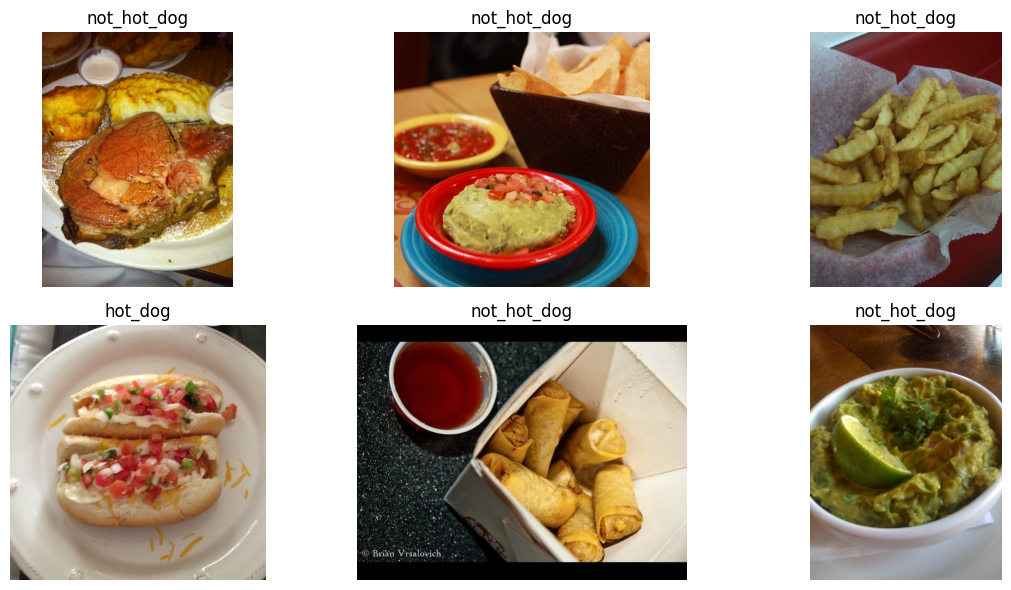

Image shape (height, width, channels): (512, 384, 3)


In [ ]:
plt.figure(figsize=(12, 6))
for i in range(6):
    class_name = random.choice(["hot_dog", "not_hot_dog"])
    class_path = os.path.join(train_path, class_name)
    img_name   = random.choice(os.listdir(class_path))
    img_path   = os.path.join(class_path, img_name)

    img = plt.imread(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.savefig("step4_sample_images.png", dpi=150)   # saves screenshot automatically
plt.show()

# Print shape of one image
print("Image shape (height, width, channels):", img.shape)


In [ ]:
IMG_HEIGHT = 64   # You can try 128 for better accuracy (slower)
IMG_WIDTH  = 64
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale          = 1./255,
    validation_split = 0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size  = BATCH_SIZE,
    class_mode  = "binary",
    subset      = "training"
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size  = BATCH_SIZE,
    class_mode  = "binary",
    subset      = "validation"
)

# Print class labels
print("Class indices:", train_generator.class_indices)


Found 400 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
Class indices: {'hot_dog': 0, 'not_hot_dog': 1}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,313 (6.03 MB)

 Trainable params: 1,581,313 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.5250 - loss: 1.9075 - val_accuracy: 0.5000 - val_loss: 1.0239
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.6000 - loss: 0.6986 - val_accuracy: 0.5714 - val_loss: 0.7069
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - accuracy: 0.6350 - loss: 0.6788 - val_accuracy: 0.5000 - val_loss: 1.1096
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.5550 - loss: 0.8140 - val_accuracy: 0.6020 - val_loss: 0.7009
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.6575 - loss: 0.6265 - val_accuracy: 0.5102 - val_loss: 0.9920
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.7125 - loss: 0.5865 - val_accuracy: 0.5000 - val_loss: 0.7407
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.7500 - loss: 0.5432 - val_accuracy: 0.5306 - val_loss: 0.7762
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.8150 - loss: 0.4677 - val_accuracy: 0.602

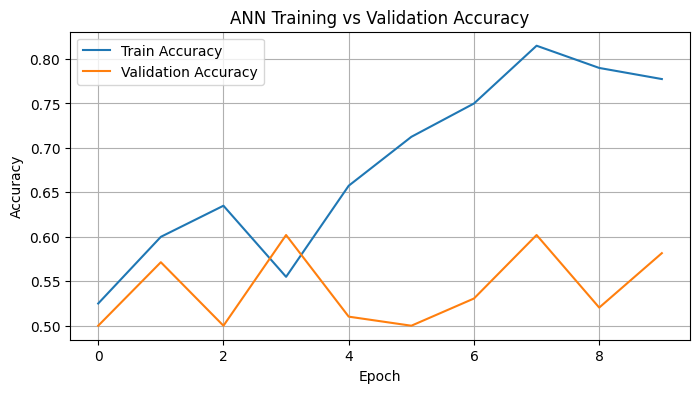

In [ ]:
ann_model = keras.Sequential([
    layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64,  activation="relu"),
    layers.Dense(1,   activation="sigmoid")
])

ann_model.compile(
    optimizer = "adam",
    loss      = "binary_crossentropy",
    metrics   = ["accuracy"]
)

ann_model.summary()

history_ann = ann_model.fit(
    train_generator,
    validation_data = validation_generator,
    epochs = 10
)

# Plot ANN training curves
plt.figure(figsize=(8, 4))
plt.plot(history_ann.history["accuracy"],     label="Train Accuracy")
plt.plot(history_ann.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("ANN Training vs Validation Accuracy")
plt.grid(True)
plt.savefig("step6_ann_accuracy.png", dpi=150)
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,905 (796.50 KB)

 Trainable params: 203,905 (796.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.5100 - loss: 0.7118 - val_accuracy: 0.5408 - val_loss: 0.6917
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 241ms/step - accuracy: 0.5300 - loss: 0.6902 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 280ms/step - accuracy: 0.5300 - loss: 0.6911 - val_accuracy: 0.5918 - val_loss: 0.6801
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 394ms/step - accuracy: 0.6475 - loss: 0.6627 - val_accuracy: 0.5918 - val_loss: 0.6786
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 242ms/step - accuracy: 0.6350 - loss: 0.6436 - val_accuracy: 0.6020 - val_loss: 0.6571
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 239ms/step - accuracy: 0.6600 - loss: 0.6286 - val_accuracy: 0.5816 - val_loss: 0.7056
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 241ms/step - accuracy: 0.6975 - loss: 0.5922 - val_accuracy: 0.6429 - val_loss: 0.6485
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 442ms/step - accuracy: 0.6875 - loss: 0.5933 - val_accuracy: 0.

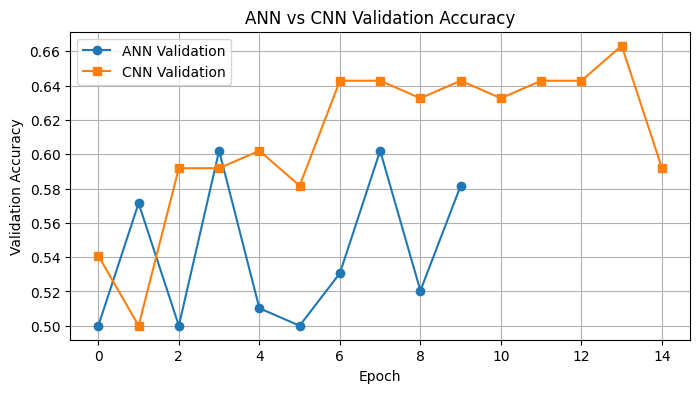

In [ ]:
cnn_model = keras.Sequential([
    # First Conv block
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second Conv block
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Third Conv block — YOUR CODE (already filled in for you)
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Fully connected head
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1,  activation="sigmoid")
])

# Compile — YOUR CODE (already filled in)
cnn_model.compile(
    optimizer = "adam",
    loss      = "binary_crossentropy",
    metrics   = ["accuracy"]
)

cnn_model.summary()

history_cnn = cnn_model.fit(
    train_generator,
    validation_data = validation_generator,
    epochs = 15
)

# ANN vs CNN comparison plot
plt.figure(figsize=(8, 4))
plt.plot(history_ann.history["val_accuracy"], label="ANN Validation", marker="o")
plt.plot(history_cnn.history["val_accuracy"], label="CNN Validation", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.title("ANN vs CNN Validation Accuracy")
plt.grid(True)
plt.savefig("step7_ann_vs_cnn.png", dpi=150)
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 371ms/step - accuracy: 0.4850 - loss: 0.7309 - val_accuracy: 0.5408 - val_loss: 0.6923
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 259ms/step - accuracy: 0.5350 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6917
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 252ms/step - accuracy: 0.5250 - loss: 0.6908 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 441ms/step - accuracy: 0.5375 - loss: 0.6918 - val_accuracy: 0.5816 - val_loss: 0.6912
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 266ms/step - accuracy: 0.5325 - loss: 0.6911 - val_accuracy: 0.6224 - val_loss: 0.6878
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 254ms/step - accuracy: 0.6025 - loss: 0.6814 - val_accuracy: 0.6122 - val_loss: 0.6769
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 257ms/step - accuracy: 0.6200 - loss: 0.6673 - val_accuracy: 0.6020 - val_loss: 0.6728
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 456ms/step - accuracy: 0.6025 - loss: 0.6407 - val_accuracy: 0

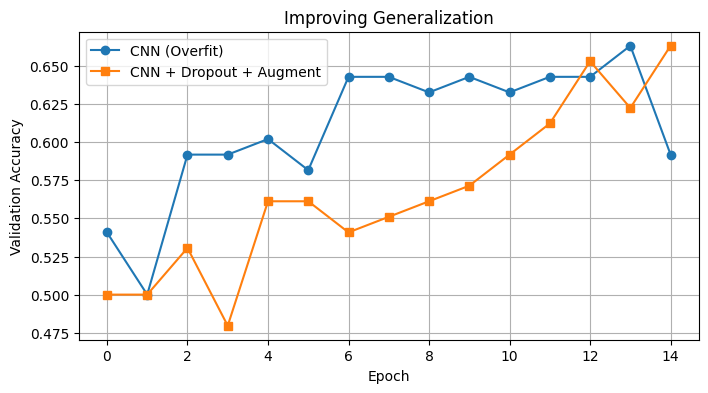


=== CNN (before fix) ===
  Train accuracy     : 85.5%
  Validation accuracy: 59.2%

=== Final Model (after Dropout + Augmentation) ===
  Train accuracy     : 60.3%
  Validation accuracy: 66.3%


In [ ]:
from tensorflow.keras import regularizers

improved_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),          # Fix 1: Dropout after 1st pool

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),          # Fix 1: Dropout after 2nd pool

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),           # Fix 1: Dropout before output

    layers.Dense(1, activation="sigmoid")
])

improved_model.compile(
    optimizer = "adam",
    loss      = "binary_crossentropy",
    metrics   = ["accuracy"]
)

history_improved = improved_model.fit(
    train_generator,
    validation_data = validation_generator,
    epochs = 15
)

# --- 8.2: Final model with Dropout + Data Augmentation ---

augmented_datagen = ImageDataGenerator(
    rescale           = 1./255,
    rotation_range    = 20,
    width_shift_range = 0.1,
    height_shift_range= 0.1,
    horizontal_flip   = True,
    validation_split  = 0.2
)

train_augmented = augmented_datagen.flow_from_directory(
    train_path,
    target_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size  = BATCH_SIZE,
    class_mode  = "binary",
    subset      = "training"
)

final_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

final_model.compile(
    optimizer = "adam",
    loss      = "binary_crossentropy",
    metrics   = ["accuracy"]
)

history_final = final_model.fit(
    train_augmented,
    validation_data = validation_generator,
    epochs = 15
)

# Before vs After overfitting plot
plt.figure(figsize=(8, 4))
plt.plot(history_cnn.history["val_accuracy"],   label="CNN (Overfit)",           marker="o")
plt.plot(history_final.history["val_accuracy"], label="CNN + Dropout + Augment", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.title("Improving Generalization")
plt.grid(True)
plt.savefig("step8_overfitting_fix.png", dpi=150)
plt.show()

# Also print final train vs val accuracy for both models
print("\n=== CNN (before fix) ===")
print(f"  Train accuracy     : {history_cnn.history['accuracy'][-1]*100:.1f}%")
print(f"  Validation accuracy: {history_cnn.history['val_accuracy'][-1]*100:.1f}%")

print("\n=== Final Model (after Dropout + Augmentation) ===")
print(f"  Train accuracy     : {history_final.history['accuracy'][-1]*100:.1f}%")
print(f"  Validation accuracy: {history_final.history['val_accuracy'][-1]*100:.1f}%")